## Student Name: 

---

# Tutorial 2: linear regression

All the parts that require action (either in the code or equations) are flagged by `<your turn>` or $\color{red}{<your~turn>}$

In [1]:
import numpy as np
import scipy.stats as st
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pylab as plt

az.style.use("arviz-vibrant")


# Setting matplotlib fonts
from matplotlib import rc
font = {'family': 'serif',
        'size': '14'}
rc('font', **font)


# Below is a set of colors for matplotlib that is colorblind-friendly
# To use them in plotting commands, you can simply set "color=colorset[N]",
# where N is an integer in [0,16), reflecting the index of the colors below.
COLORSET = ['#000000','#00270C','#00443C','#005083',
            '#034BCA','#483CFC','#9C2BFF','#EB24F4',
            '#FF2DC2','#FF4986','#FF7356','#FFA443',
            '#EBD155','#D3F187','#D7FFC8','#FFFFFF']

### Data

Starting with the example in the lecture, we have made $N$ independent measurements of a quantity $Y$ (with each measurement containing normally-distributed uncertainties), at different values of quantity $X$. Assuming $Y$ as a function of $X$, we want to infer a model for the "model" $Y$ (which we label $Y_{\rm{Model}}$), given what we can *observe* as $Y$ ($Y_{\rm{obs}}$).


Our data consists of three numbers per measurement:

$$ x = [x_1,\cdots,x_N] $$
$$ \hat{y}_{\rm{obs}} = [\hat{y}_1,\cdots,\hat{y}_N] $$
$$ \hat{\sigma} = [\hat{\sigma}_1,\cdots,\hat{\sigma}_N] $$


In this unit we will use [Pandas](https://pandas.pydata.org/) for data operations. Here is [a quick cheat sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf) for using Pandas.

In [2]:
DATA = pd.read_csv('https://raw.githubusercontent.com/bersavosh/P4003/refs/heads/main/Tutorials/T2_data.csv')
DATA.head()

,x,y_obs,sigma_obs
0,7.083817,41.284397,4.086769
1,12.730708,73.958291,4.721005
2,14.047957,87.130428,4.967181
3,13.352799,74.054368,3.906344
4,7.268085,45.789048,4.254728


### EDA
#### Exercise: Make a scatter plot the measurements and uncertainties of $\hat{y}_{\rm{obs}}$ as a function of $x$. To do this, you can simply use `plt.errorbar()` in matplotlib.

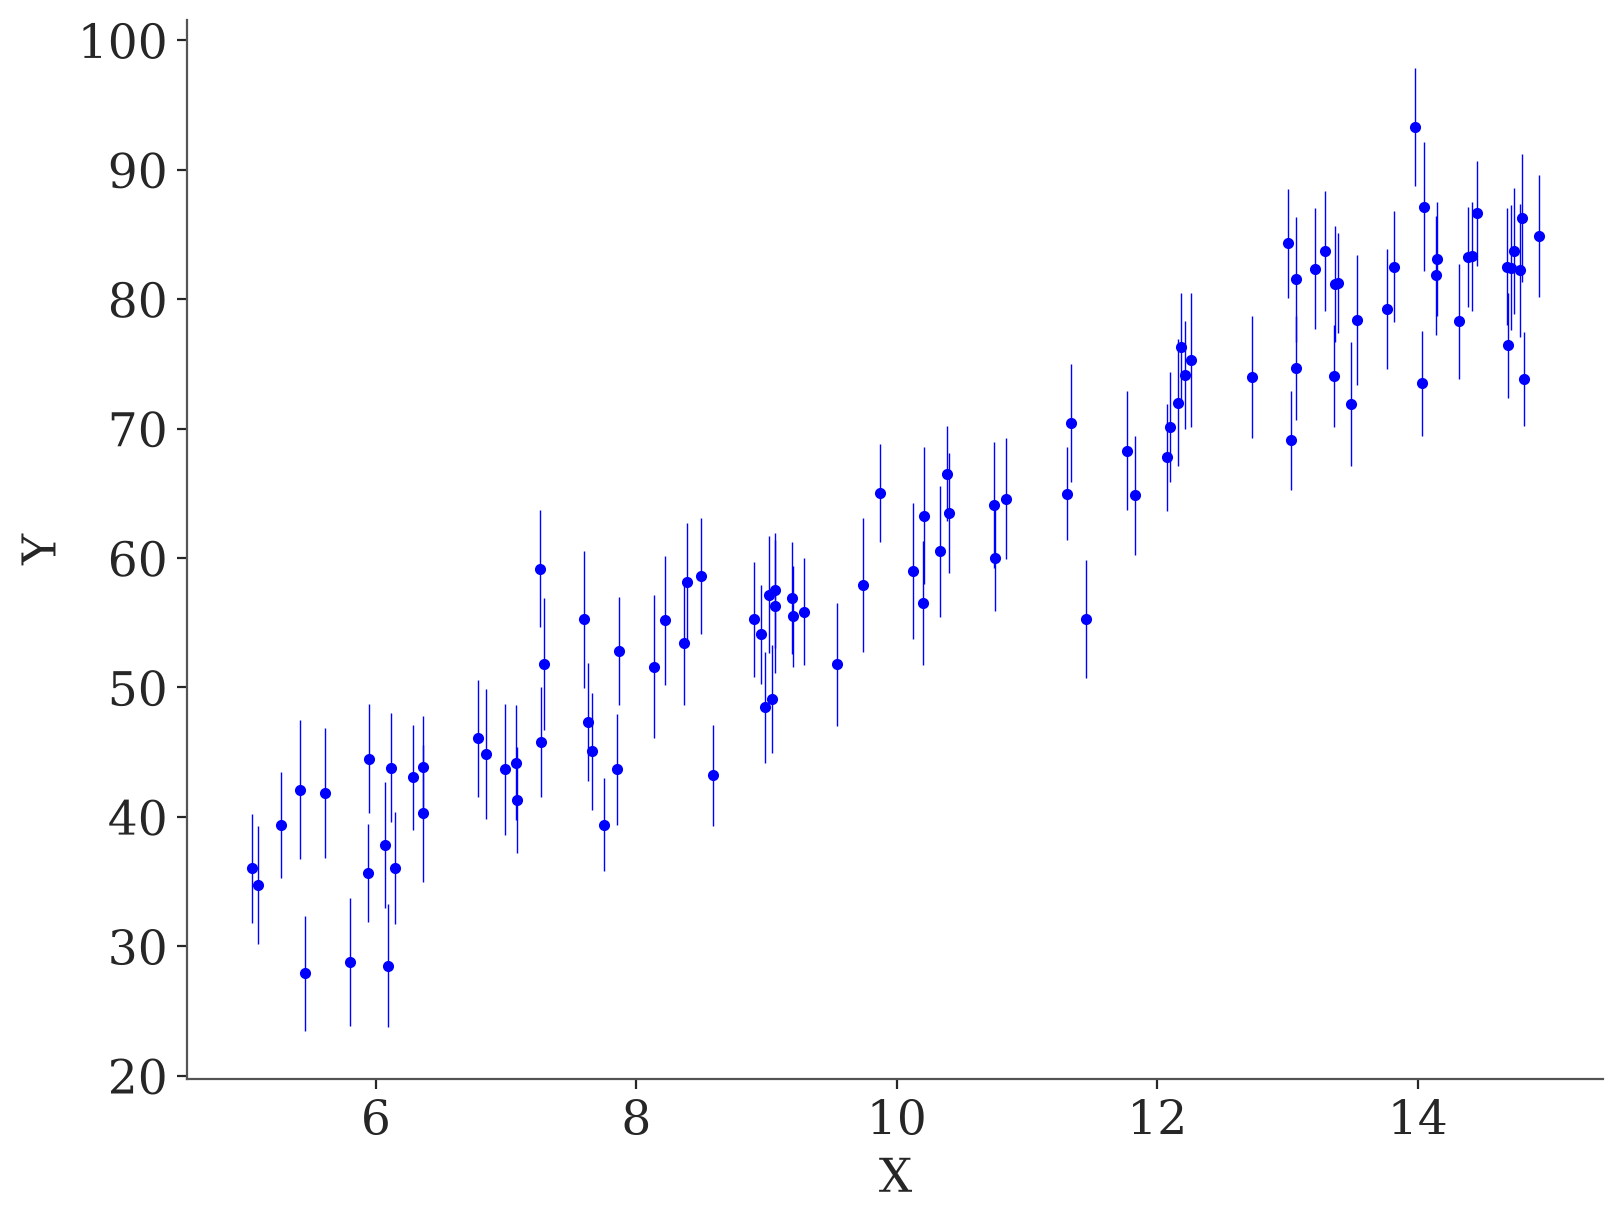

In [3]:
# <your turn>

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.errorbar(x=DATA['x'],
            yerr=DATA['sigma_obs'],
            y=DATA['y_obs'],
            fmt='.b', elinewidth=0.5)

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

### Our model

Similar to the lecture, we assume that our understanding of the physics, hypothetically, suggest that 
$$ Y_{\rm{Model}}(x; m, d) = m x + d $$

and similar to the lecture we assume the following priors on $m$ and $d$:

$$ m \sim \textrm{Uniform}(\min=0,\max=10) $$
$$ d \sim \textrm{Uniform}(\min=-20,\max=20) $$

and we define that

$$ \hat{Y}_{\rm{obs}} \sim \textrm{Normal}(Y_{\rm{Model}}(x),\sigma_Y) $$

and we remember that we consider $\hat{y}_{\rm{obs}} = [\hat{y}_1,\cdots,\hat{y}_N]$ as random draws of $\hat{Y}_{\rm{obs}}$.



#### Exercise - part a: Build a PyMC model with the variables above. With the following steps:
 - Start with the data. Data can be defined in a PyMC model using `pm.Data`.
 - Then add the model parameters and variables we have defined above.

In [4]:
# <your turn>
# just define the model and its components, no sampling or plotting needed here.

with pm.Model() as regression_model:
    ## First define your data here:
    x = pm.Data('x', DATA['x'])
    y_obs = pm.Data('y_obs', DATA['y_obs'])
    sigma_obs = pm.Data('sigma_obs', DATA['sigma_obs'])

    ## Now define your model variables
    m = pm.Uniform('m', 0, 10)
    d = pm.Uniform('d', -20, 20)
    Y_model = pm.Deterministic('Y_model', m*x+d)
    Y_obs = pm.Normal('Y_obs', mu=Y_model, sigma=sigma_obs)

# No plotting or sampling needed yet.

#### Exercise - part b: Explore the model structures by making a diagram of model's [plate notation](https://en.wikipedia.org/wiki/Plate_notation). For this purpose, you can use `pm.model_to_graphviz` (see documentation [here](https://www.pymc.io/projects/docs/en/v5.6.1/api/generated/pymc.model_to_graphviz.html)).

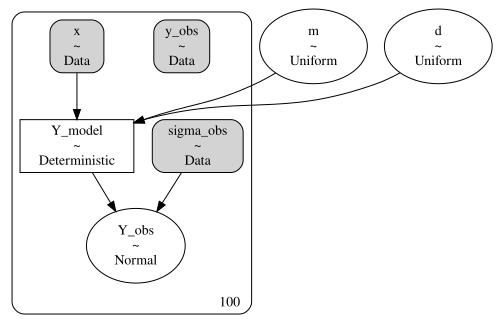

In [5]:
# <your turn>

pm.model_to_graphviz(regression_model)

#### Exercise - part c: Our model has a problem, can you spot it? fix the issue in the cell below and replot the plate notation. 
(*hint: where is the link between our data and $\hat{Y}_{\rm{obs}}$ variable?*)

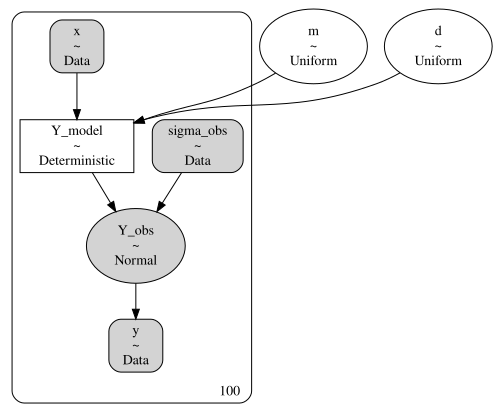

In [6]:
# <your turn>
# redefine the model and replot the model graph

with pm.Model() as regression_model:
    ## First define your data here:
    x = pm.Data('x', DATA['x'])
    y_obs = pm.Data('y', DATA['y_obs'])
    sigma_obs = pm.Data('sigma_obs', DATA['sigma_obs'])

    ## Now define your model variables
    m = pm.Uniform('m',0,10)
    d = pm.Uniform('d',-20,20)
    Y_model = pm.Deterministic('Y_model', m*x+d)
    Y_obs = pm.Normal('Y_obs', mu=Y_model, sigma=sigma_obs, observed=y_obs)


# graph visualization can be put under here
pm.model_to_graphviz(regression_model)

### MCMC sampling

Note that we are now actually performing MCMC (and not MC).

#### Exercise - part a: perform sampling with the model we defined above. Run your sampling with `discard_tuned_samples=False`.

In [7]:
# <your turn>

with regression_model:
    regression_mcmc_sample = pm.sample(discard_tuned_samples=False, draws=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m, d]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
Sampling: [Y_obs]


Output()

#### Exercise - part b: Assess sampling performance. Think about what the sampling progress bar and table show. Print the resulting inference data `regression_mcmc_sample` to explore what is captured.

In [8]:
# <your turn>

regression_mcmc_sample

<xarray.DataTree>
Group: /
├── Group: /warmup_posterior
│       Dimensions:        (chain: 4, draw: 1000, Y_model_dim_0: 100)
│       Coordinates:
│         * chain          (chain) int64 32B 0 1 2 3
│         * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * Y_model_dim_0  (Y_model_dim_0) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
│       Data variables:
│           m              (chain, draw) float64 32kB 3.361 3.361 3.361 ... 5.138 5.138
│           d              (chain, draw) float64 32kB -4.118 -4.118 ... 8.313 8.313
│           Y_model        (chain, draw, Y_model_dim_0) float64 3MB 19.69 ... 48.72
│       Attributes:
│           created_at:                 2026-07-31T00:56:46.867607+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.747772455215454
│           tuning_steps:               1000
├── Group: /posterior
│       Dimensions:        (chain: 4, draw: 1000, Y_model_dim_0: 100)
│       Coordinates:
│         * chain          (chain) int64 32B 0 1 2 3
│         * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * Y_model_dim_0  (Y_model_dim_0) int64 800B 0 1 2 3 4 5 ... 94 95 96 97 98 99
│       Data variables:
│           m              (chain, draw) float64 32kB 5.173 5.177 5.121 ... 5.161 5.257
│           d              (chain, draw) float64 32kB 7.803 8.291 8.354 ... 8.264 7.045
│           Y_model        (chain, draw, Y_model_dim_0) float64 3MB 44.45 ... 48.39
│       Attributes:
│           created_at:                 2026-07-31T00:56:46.871829+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.747772455215454
│           tuning_steps:               1000
├── Group: /warmup_sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           divergences            (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│           energy                 (chain, draw) float64 32kB 2.809e+03 ... 307.3
│           largest_eigval         (chain, draw) float64 32kB nan nan nan ... nan nan
│           acceptance_rate        (chain, draw) float64 32kB 0.0 0.0 0.0 ... 1.0 0.8544
│           step_size              (chain, draw) float64 32kB 0.4909 0.0484 ... 0.3959
│           max_energy_error       (chain, draw) float64 32kB 1.002e+05 ... 0.3271
│           ...                     ...
│           diverging              (chain, draw) bool 4kB True True True ... False False
│           tree_depth             (chain, draw) int64 32kB 1 1 1 1 1 4 ... 3 3 2 4 1 3
│           perf_counter_diff      (chain, draw) float64 32kB 0.1053 ... 0.000321
│           index_in_trajectory    (chain, draw) int64 32kB 0 0 0 1 -1 4 ... -3 1 5 1 0
│           perf_counter_start     (chain, draw) float64 32kB 1.321e+05 ... 1.321e+05
│           lp                     (chain, draw) float64 32kB -2.809e+03 ... -306.6
│       Attributes:
│           created_at:                 2026-07-31T00:56:46.882172+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│        

#### Exercise - part c: Use `az.plot_trace` to look at how your chains have "walked" (use `var_names=['m','d']` to focus on just these parameters). First do this for `posterior` (the default), then do the same for `warmup_posterior`. Do you notice anything unusual?

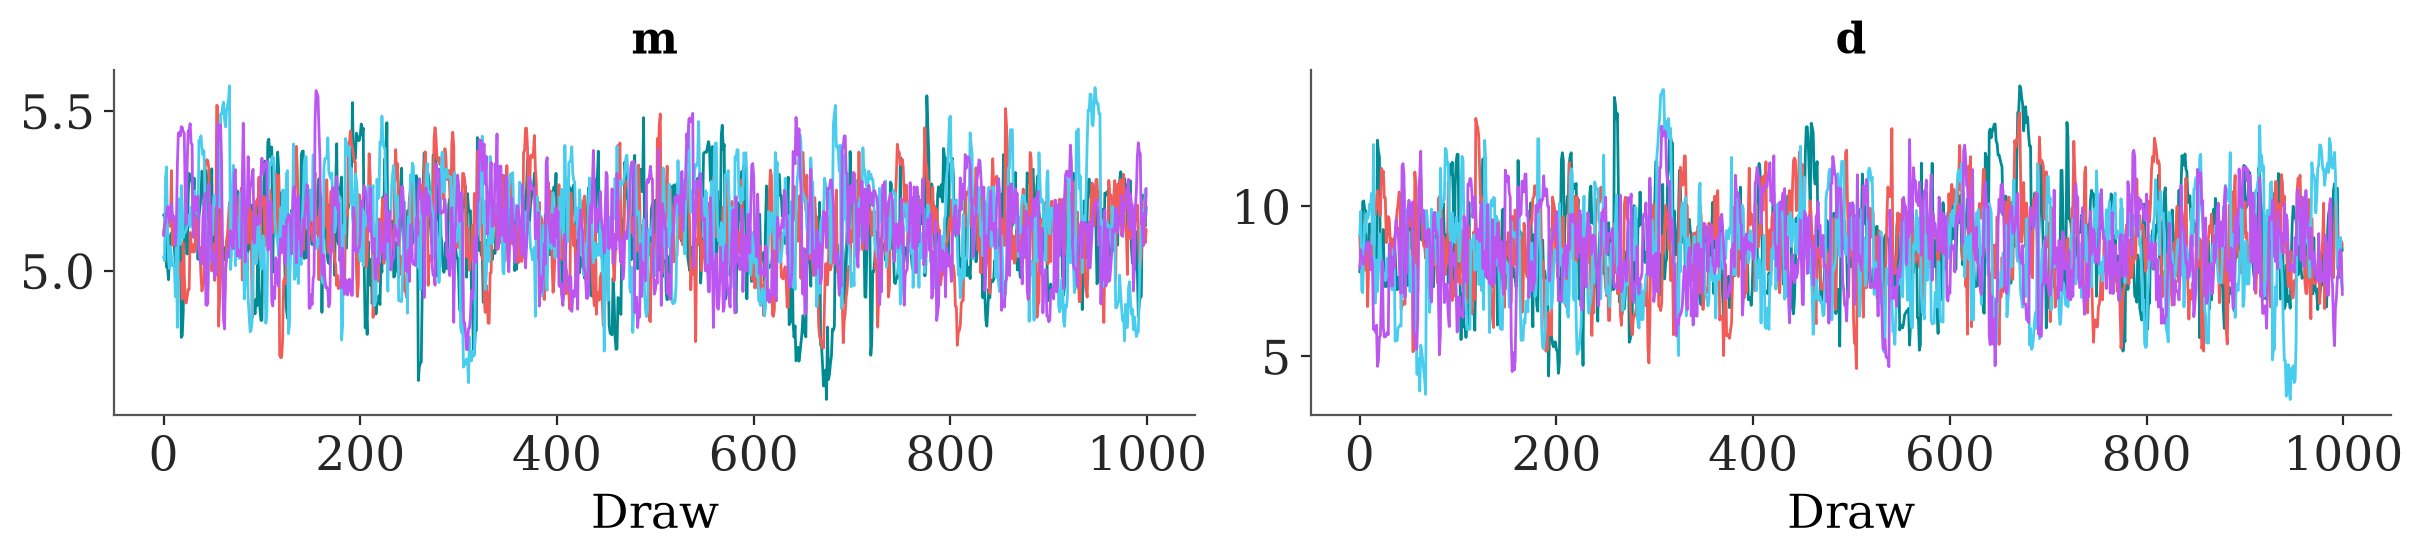

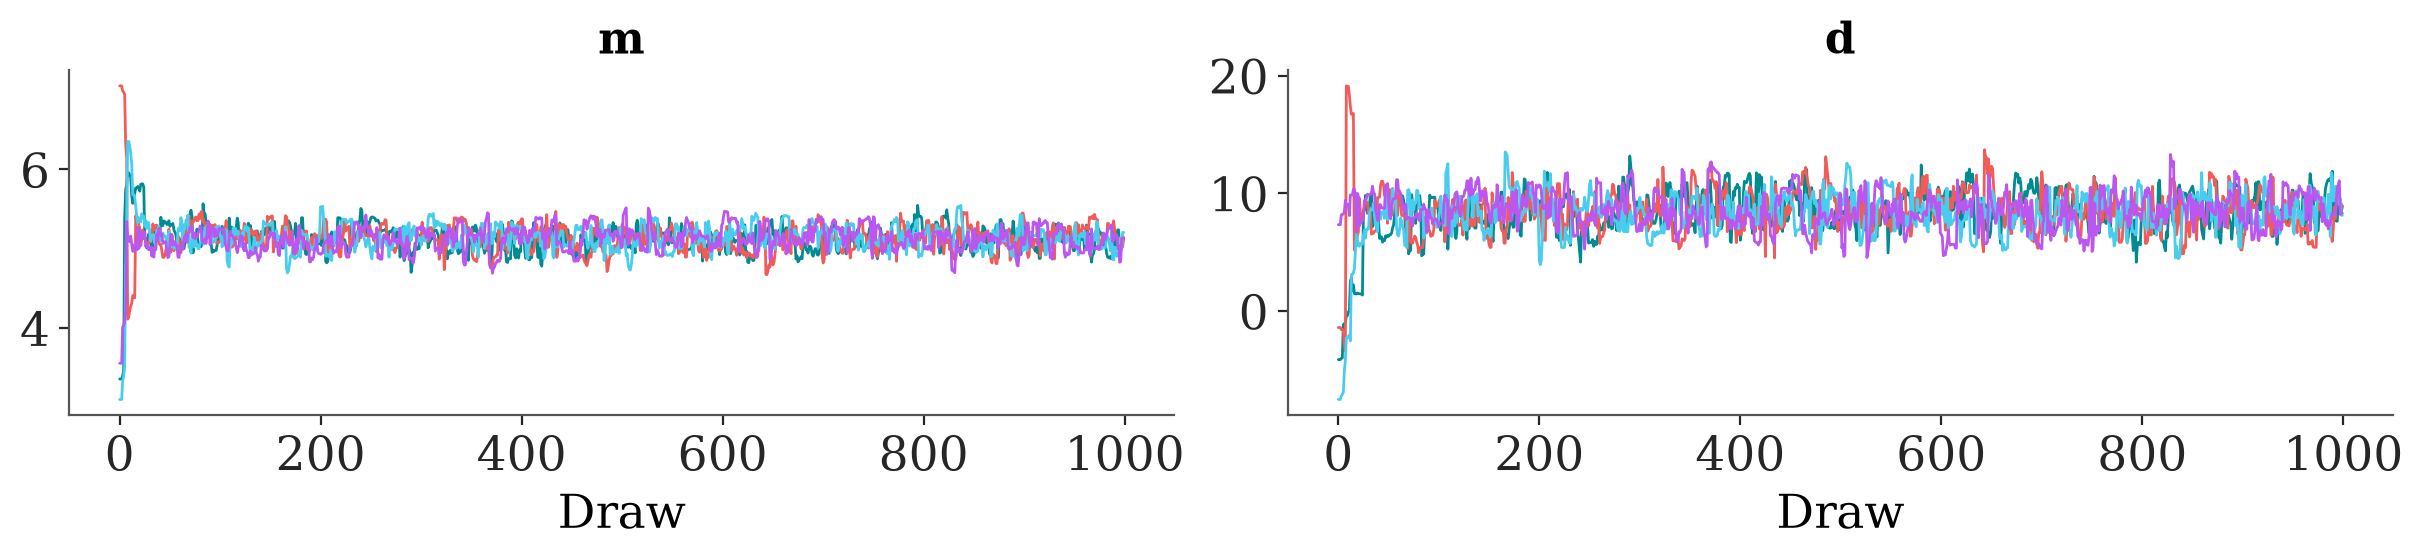

In [9]:
# <your turn>

# Posterior
az.plot_trace(regression_mcmc_sample, var_names=['m','d'], 
              visuals={'trace':{'width':1}}) # this defauls to "regression_mcmc_sample.posterior"

# Warmup
az.plot_trace(regression_mcmc_sample, group="warmup_posterior", var_names=['m','d'],
              visuals={'trace':{'width':1}})

### Model fitting results

#### Exercise - part a: Print summary of the posterior with `pm.summary`. Think about what the values in the summary table mean. Use 68% HDI probability for interval estimation.

In [10]:
# <your turn>

fit_summary = pm.stats.summary(regression_mcmc_sample, var_names=['m', 'd'], ci_prob=0.68, )
fit_summary

,mean,sd,eti68_lb,eti68_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
m,5.13,0.148,5,5.3,614,797,1.00,0.006,0.0043
d,8.6,1.58,7.1,10,605,721,1.00,0.065,0.047


#### Exercise - part b: using plotting functions we have discussed in earlier exercises, plot the marginal posterior samples of $m$ and $d$.

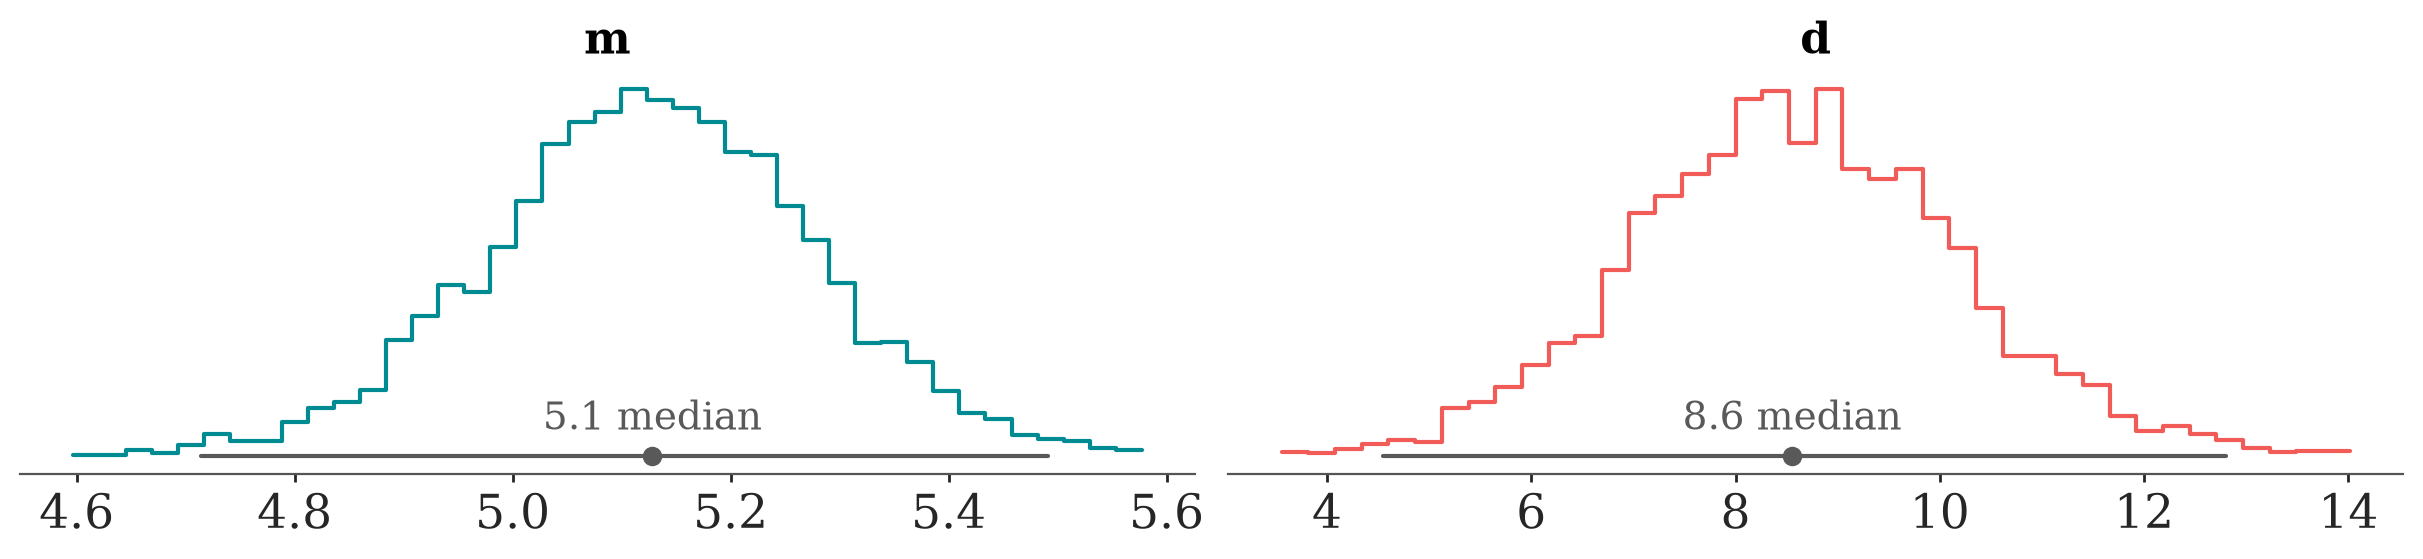

In [11]:
az.plot_dist(regression_mcmc_sample,
             var_names=['m','d'],
             point_estimate = 'median',
             ci_kind='hdi', ci_prob=0.99,
             kind="hist", 
             aes={"color": ["__variable__"]}
            );

#### Exercise - part c: using plotting functions we have discussed in earlier exercises, plot the joint and margian posterior samples of $m$ and $d$.

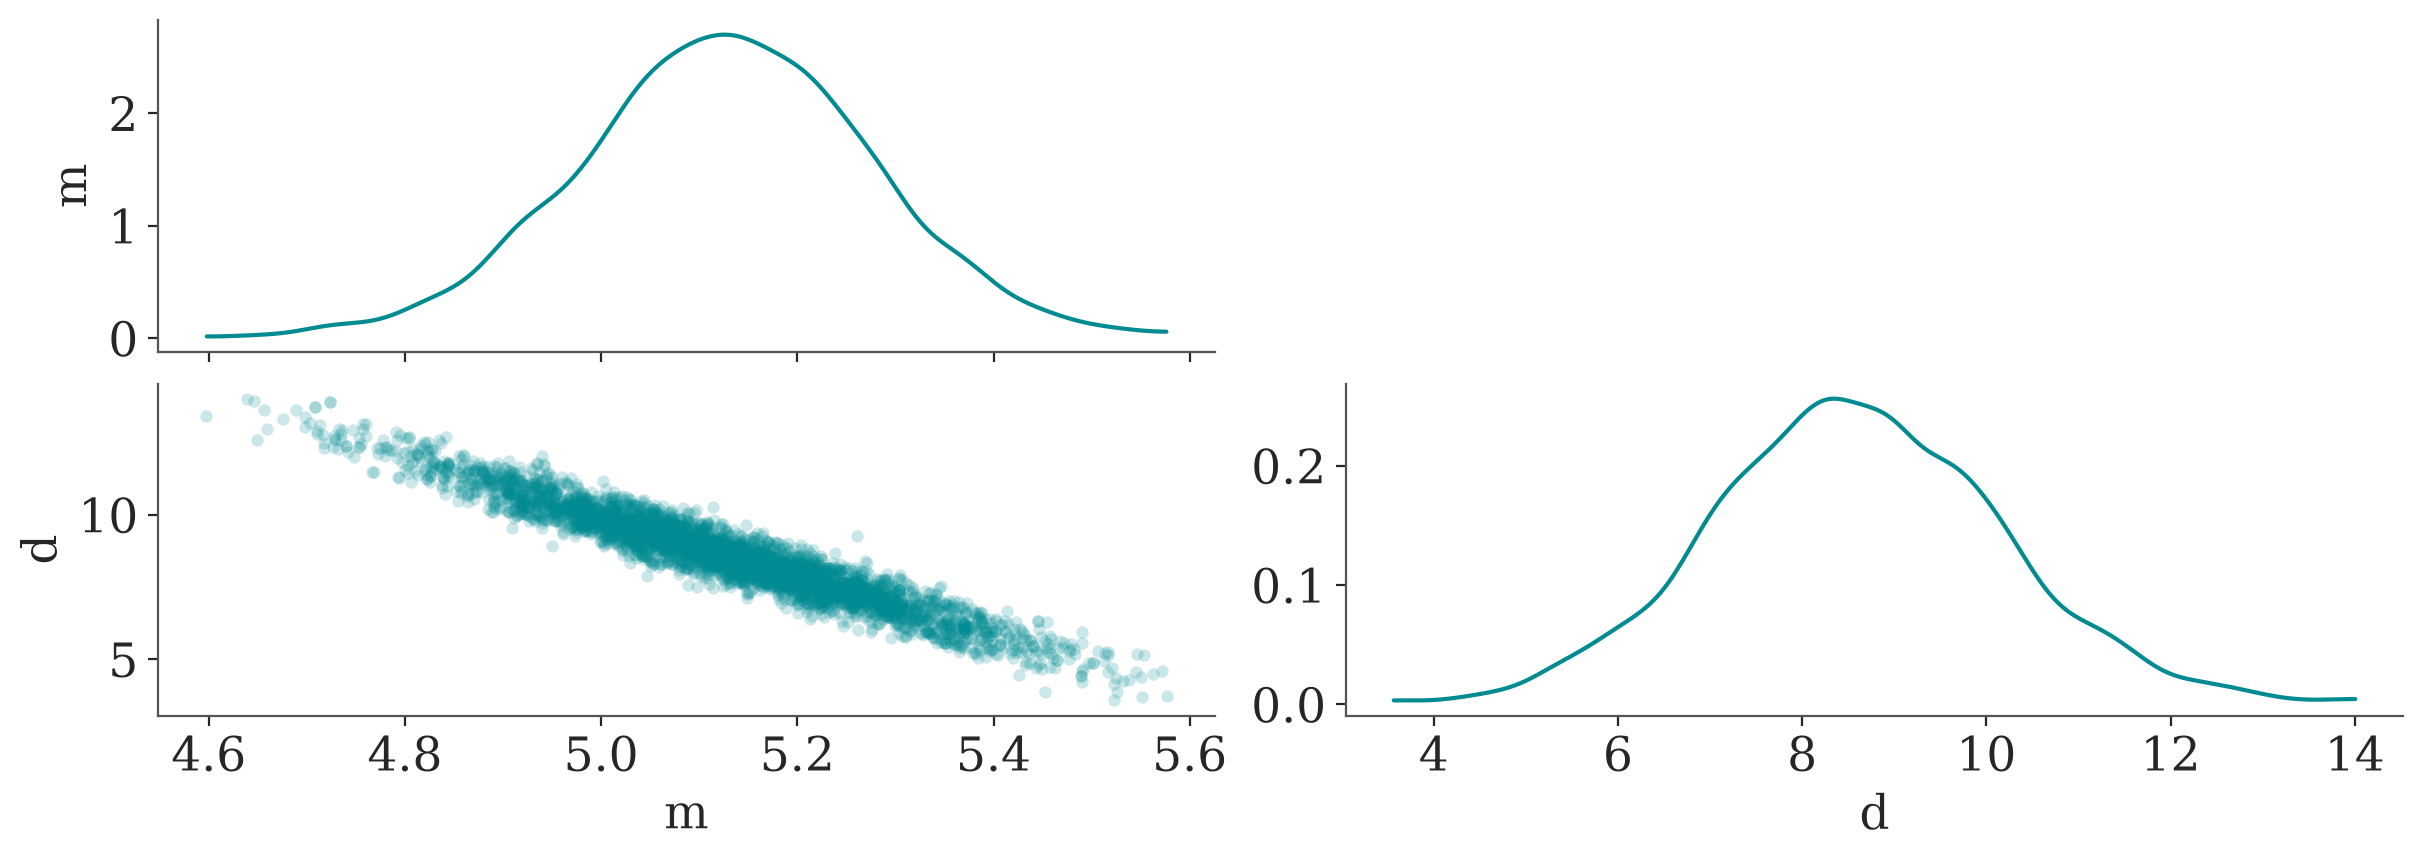

In [12]:
# <your turn>

az.plot_pair(regression_mcmc_sample, var_names=['m', 'd'], marginal=True,
             visuals={'scatter':{'alpha':0.2, 'size':20}})

#### Exercise - part d: Reuse your code from plotting the data, and add a line representing the model with posterior means.
*hint: you can extract the exact values from your inference data `regression_mcmc_sample.posterior['m'].mean().values`. You can also try using the XArray `data` group, instead of our initial Pandas data frame.

In [ ]:
# <your turn>


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

# <your turn>





ax.plot(test_x, test_y, color=COLORSET[7],label='Model posterior mean')

ax.legend()

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

#### Exercise - part e: Reuse your code from plotting above, and plot a sample of lines using posteriors of $m$ and $d$.

In [ ]:
# <your turn>


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)

# <your turn>





ax.plot(test_x, test_y, color=COLORSET[7],label='Model posterior mean')

ax.legend()

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

Does the plot above look right? Does our approach make sense? Anything suspicious? 

## You can now save the notebook and download it.